In [ ]:
# Mitsui Target Calculation Example: https://www.kaggle.com/code/sohier/mitsui-target-calculation-example/

In [ ]:
# # Import Kaggle evaluation API: 待完成 (Mitsui Demo Submission: https://www.kaggle.com/code/sohier/mitsui-demo-submission)
# import kaggle_evaluation.mitsui_inference_server

In [1]:
# Mount to Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Define project folder
FOLDERNAME = 'Colab Notebooks/MITSUI&CO. Commodity Prediction Challenge'
%cd drive/MyDrive/$FOLDERNAME

Mounted at /content/drive
/content/drive/MyDrive/Colab Notebooks/MITSUI&CO. Commodity Prediction Challenge


In [2]:
# 比賽規定CPU, GPU <= 8hr
import time  # 提供與時間相關的功能，例如：計時、格式化時間、處理時間戳等
start_time = time.time()

cuda

=== Training with SEQ_LEN = 20 ===
Training price model with Seq2SeqAutoRegressive for SEQ_LEN=20
Epoch 1: TFR=0.9000, Train Loss=0.567457, Val Loss=0.831919
Epoch 10: TFR=0.8182, Train Loss=0.015941, Val Loss=0.048986
Epoch 20: TFR=0.7273, Train Loss=0.014265, Val Loss=0.093338
Early stopping at epoch 23
Training log return model with Seq2SeqAutoRegressive for SEQ_LEN=20
Epoch 1: TFR=0.9000, Train Loss=0.499188, Val Loss=0.545748
Epoch 10: TFR=0.8182, Train Loss=0.422774, Val Loss=0.411723
Epoch 20: TFR=0.7273, Train Loss=0.333605, Val Loss=0.319831
Epoch 30: TFR=0.6364, Train Loss=0.297613, Val Loss=0.329827
Epoch 40: TFR=0.5455, Train Loss=0.258588, Val Loss=0.238841
Epoch 50: TFR=0.4545, Train Loss=0.222761, Val Loss=0.194953
Epoch 60: TFR=0.3636, Train Loss=0.200055, Val Loss=0.180992
Epoch 70: TFR=0.2727, Train Loss=0.169939, Val Loss=0.177623
Early stopping at epoch 75

=== Seq2SeqAutoRegressive Performance Summary for SEQ_LEN=20 ===
Price Prediction (Price Model):
  t+2: 

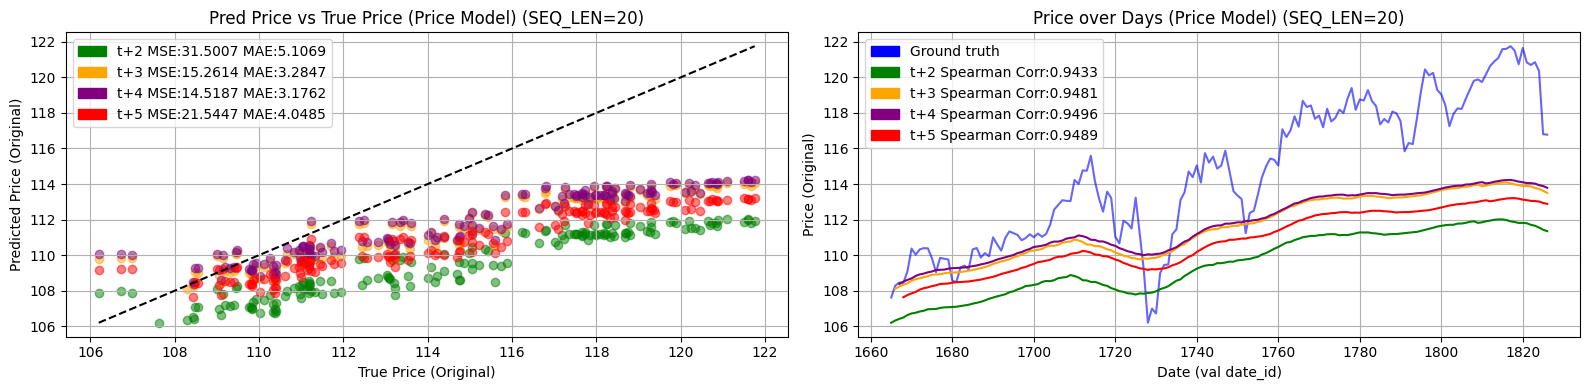

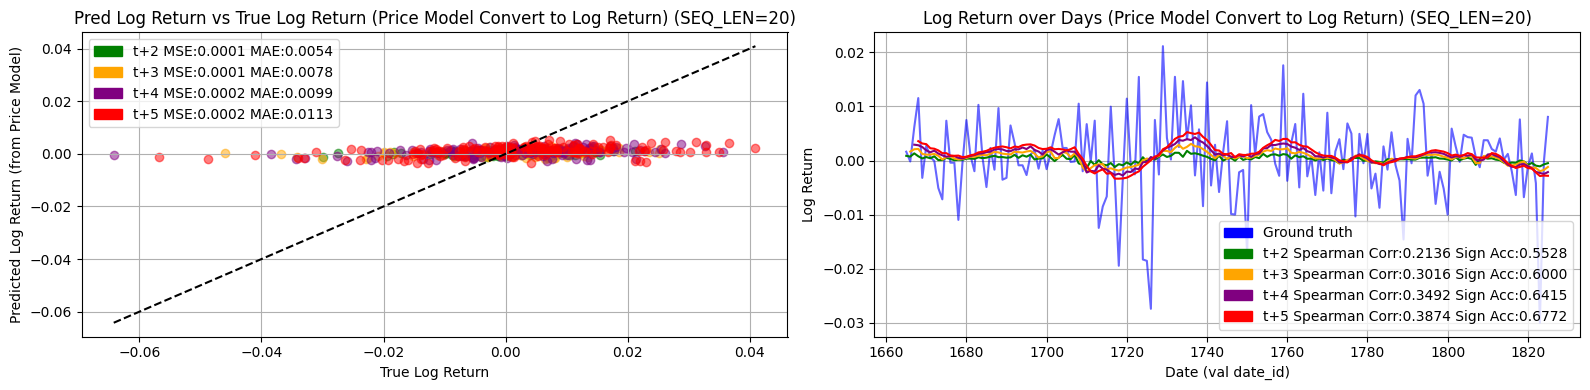

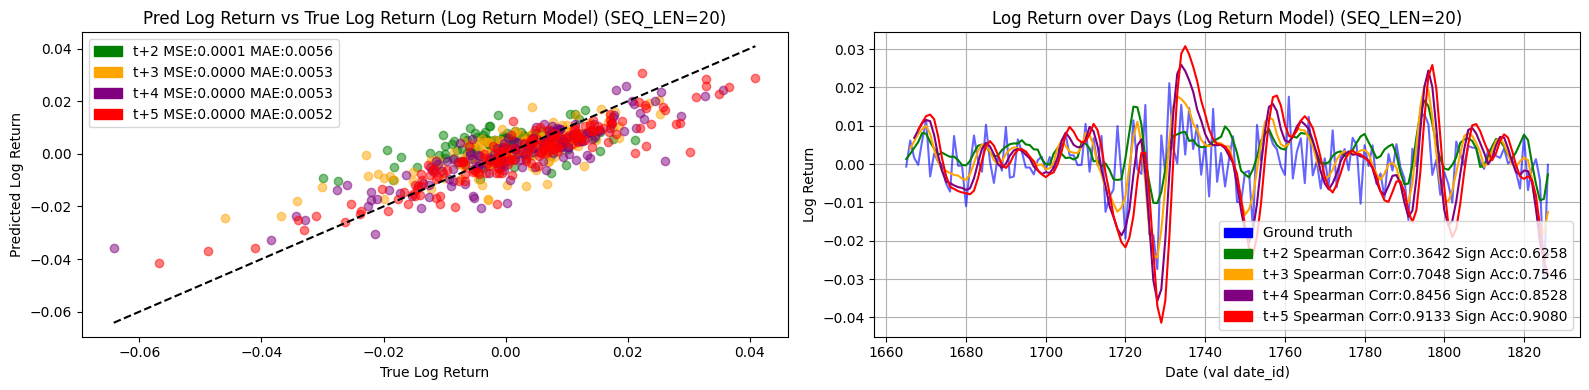

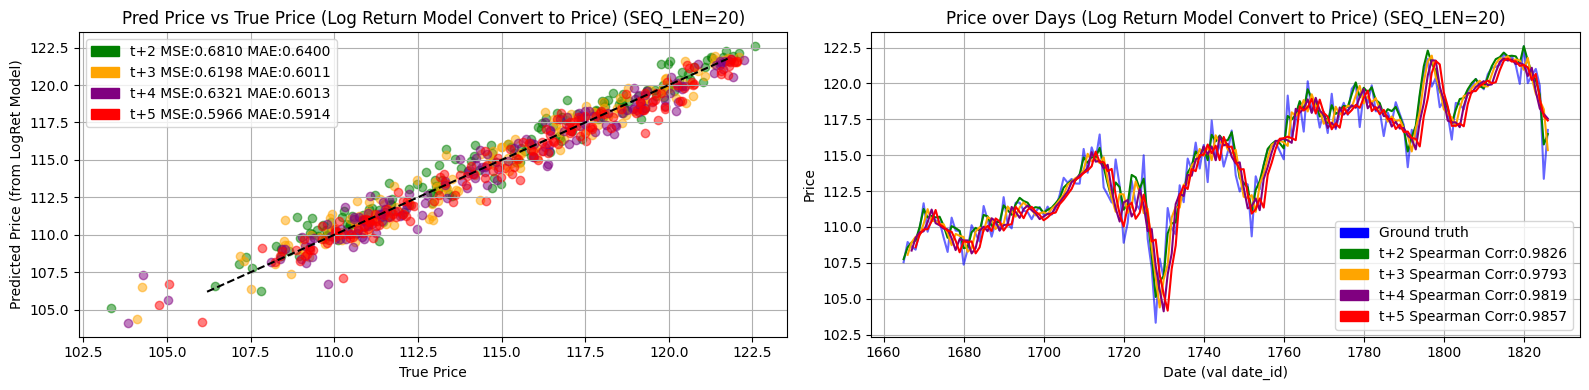


=== Training with SEQ_LEN = 45 ===
Training price model with Seq2SeqAutoRegressive for SEQ_LEN=45
Epoch 1: TFR=0.9000, Train Loss=0.481691, Val Loss=0.521824
Epoch 10: TFR=0.8182, Train Loss=0.015877, Val Loss=0.163721
Epoch 20: TFR=0.7273, Train Loss=0.012706, Val Loss=0.081370
Epoch 30: TFR=0.6364, Train Loss=0.011240, Val Loss=0.046679
Epoch 40: TFR=0.5455, Train Loss=0.013614, Val Loss=0.026597
Epoch 50: TFR=0.4545, Train Loss=0.010822, Val Loss=0.061836
Early stopping at epoch 56
Training log return model with Seq2SeqAutoRegressive for SEQ_LEN=45
Epoch 1: TFR=0.9000, Train Loss=0.495523, Val Loss=0.584420
Epoch 10: TFR=0.8182, Train Loss=0.421492, Val Loss=0.410930
Epoch 20: TFR=0.7273, Train Loss=0.379288, Val Loss=0.575051
Epoch 30: TFR=0.6364, Train Loss=0.294069, Val Loss=0.395031
Epoch 40: TFR=0.5455, Train Loss=0.255275, Val Loss=0.251410
Epoch 50: TFR=0.4545, Train Loss=0.242383, Val Loss=0.195766
Epoch 60: TFR=0.3636, Train Loss=0.197111, Val Loss=0.201307
Epoch 70: TFR=0

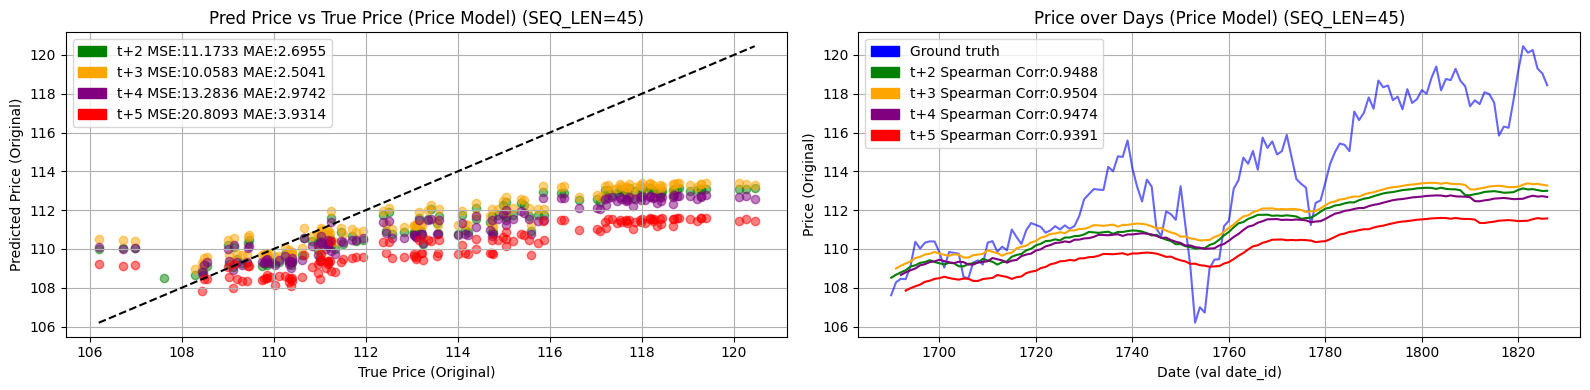

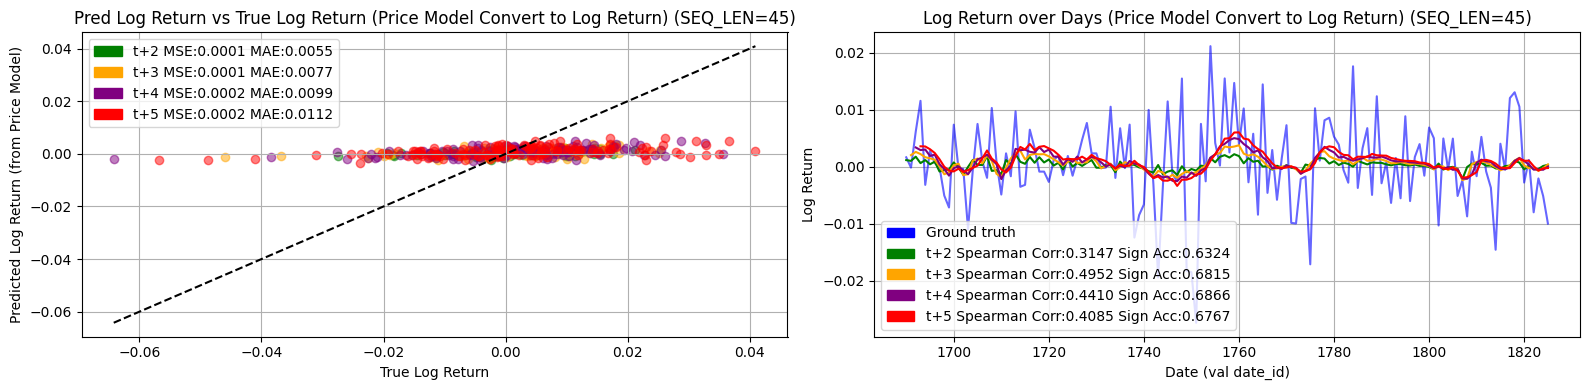

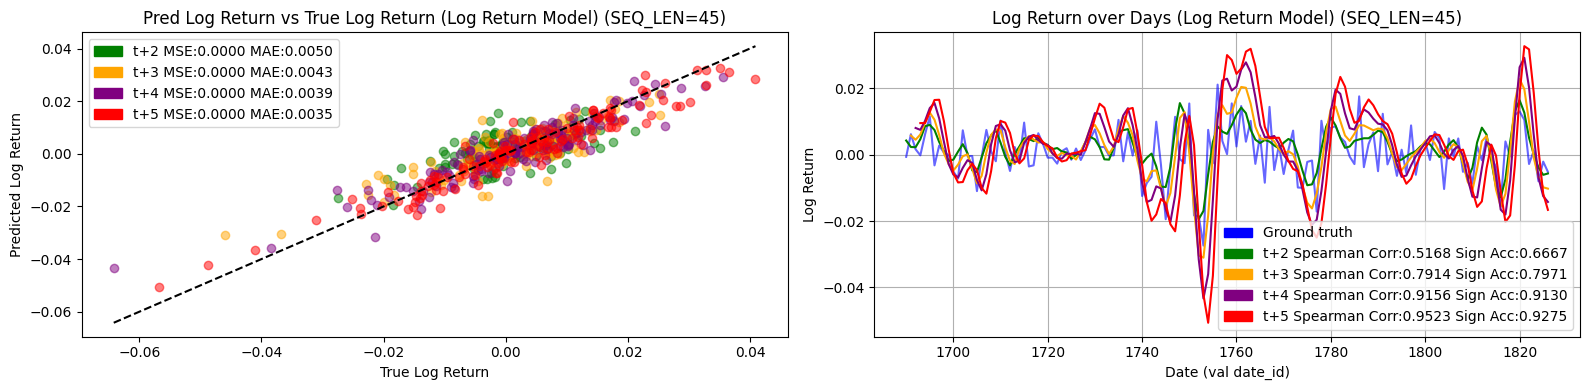

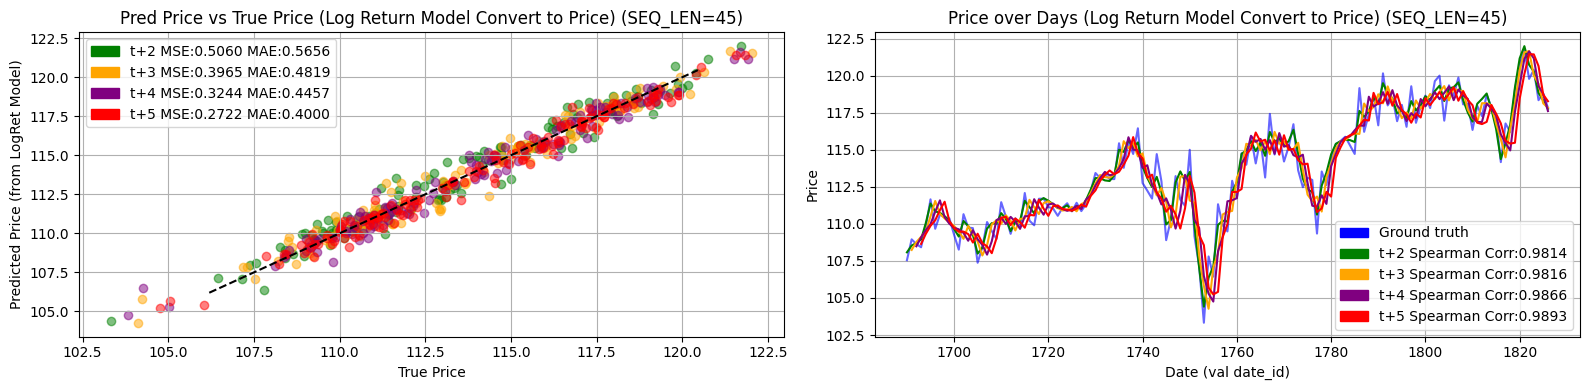

In [10]:
# Import packages
import math  # 提供標準數學函式與常數，例如：sin, cos, tan, log, exp, sqrt, pi等
import random  # Python內建的偽隨機模組，產生隨機數、打亂序列、抽樣等
import numpy as np  # 提供高效的多維陣列(ndarray)、broadcasting、向量化運算等
import pandas as pd  # 提供DataFrame / Series結構，方便資料讀取(CSV/Excel/SQL)、清洗、缺失值處理等
import os  # 作業系統操作：檔案與目錄處理(os.path.join, os.listdir, os.makedirs)、環境變數存取(os.environ)、檔案存在檢查(os.path.exists)等
import copy  # 提供淺拷貝(copy.copy)與深拷貝(copy.deepcopy)，避免直接操作原始物件導致資料被意外修改

from scipy.stats import spearmanr  # 計算Spearman相關係數(檢查變數間是否存在單調關係)
from scipy.interpolate import interp1d  # 插值函式庫，方便對缺失值做插補；interp1d會回傳可呼叫的插值器(linear/quadratic/cubic...)

from sklearn.feature_selection import VarianceThreshold, SelectKBest, mutual_info_regression, SelectFromModel  # 特徵選擇工具：VarianceThreshold(移除低變異欄位)、SelectKBest(搭配評分函式選前K個特徵)、mutual_info_regression(計算特徵與目標之間的互信息分數)、SelectFromModel(根據已訓練模型的重要性或係數自動選特徵)
from sklearn.ensemble import RandomForestRegressor  # 隨機森林回歸器：ensemble 決策樹，可做回歸、非線性擬合，並提供 feature_importances_ 作為特徵重要性評估
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler  # 資料標準化：StandardScaler(零均值單位變異)、MinMaxScaler(縮到指定範圍)、RobustScaler(以中位數與IQR抵抗離群值)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score  # 回歸評估指標：MSE(均方誤差)、MAE(平均絕對誤差)、R^2決定係數(解釋變異比例)

import torch  # PyTorch主套件：tensor運算、自動微分、GPU加速、模型載入等
import torch.nn as nn  # PyTorch神經網路模：包含nn.Module、常見層(Linear, Conv, BatchNorm, Dropout)、activation、loss等
import torch.nn.functional as F  # 提供函數式的操作，例如激活函數(ReLU, Sigmoid)、損失計算(cross_entropy)等，通常與 nn.Module 不同層，不會儲存參數
from torch.utils.data import Dataset, DataLoader  # 用於定義自訂Dataset(__len__, __getitem__)，透過DataLoader批次化、打亂、載入資料等
from torch.optim import lr_scheduler  # 學習率調整器：StepLR(每隔固定epoch降低LR)、ExponentialLR(每次乘上decay rate)、ReduceLROnPlateau(val_loss沒進步就降LR)

import matplotlib.pyplot as plt  # Matplotlib：Python基礎繪圖庫，提供圖表繪製(折線圖、散佈圖、長條圖等)、圖形儲存(savefig)、顯示(show)
import matplotlib.patches as mpatches  # Matplotlib圖例補丁工具：自訂圖例標記(Patch, Rectangle等)
import seaborn as sns  # 基於Matplotlib的高階統計繪圖套件：提供更簡潔API(heatmap、pairplot、violinplot等)

# Suppress all warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Use GPU if available, else CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# Reproducibility
def set_seed(seed=42):
    random.seed(seed)  # 設定Python內建random模組的種子
    np.random.seed(seed)  # 設定NumPy隨機種子
    torch.manual_seed(seed)  # 設定PyTorch CPU隨機種子
    if torch.cuda.is_available():  # 檢查是否有可用的GPU
        torch.cuda.manual_seed(seed)  # 設定當前GPU的隨機種子
        torch.cuda.manual_seed_all(seed)  # 設定所有GPU的隨機種子
    torch.backends.cudnn.deterministic = True  # 確保CUDNN操作具有確定性
    torch.backends.cudnn.benchmark = False  # 關閉CUDNN自動優化以確保一致性

set_seed(42)  # 執行種子設定

# Target
target_col = 'US_Stock_VT_adj_close' # 試試其他的商品：'US_Stock_VT_adj_close', 'LME_PB_Close', 'JPX_Gold_Standard_Futures_Close', 'FX_EURCHF'

# Model可選擇："Seq2SeqAutoRegressive", "Seq2SeqMLPAutoRegressive"
MODEL_TYPE = "Seq2SeqAutoRegressive"

# Parameters
SEQ_LENS = [20, 45]  # 滑動視窗長度(sliding window)；短 → 模型偏向捕捉短期波動；長 → 模型學習長期趨勢 (預測股價約5-60)
LAGS = [1, 2, 3, 4]  # 要預測的滯後期(lag horizon)；代表要預測未來第 t+lag+1 天

# Model
HIDDEN_SIZE = 128  # LSTM隱藏層維度(控制模型表達能力)；數值越大，模型有越多學習機會，但也可能overfitting (常見範圍32-512)
NUM_LAYERS = 2  # LSTM層數(stacked LSTM)；1層 → 訓練快，可能表現不足；多層 → 需要更多參數，擬合更複雜的序列關係 (常見範圍1-3)
DROPOUT = 0.3  # 關閉30%的神經元連結，防止overfitting (常見範圍0.1-0.5)
OUTPUT_SIZE = len(LAGS)  # LSTM輸出大小；這裡設為len(LAS)，代表模型要同時輸出未來4個值；若只預測未來一天，則設為1

# Teacher Forcing Ratio
INITIAL_TFR = 0.9  # 初始TFR → 訓練時90%使用正確的目標值，10%使用模預測值，作為下一步輸入
FINAL_TFR = 0.0  # 最終TFR → 訓練到最後的epoch，模型不使用正確的目標值，增加泛化能力

# # Loss Function
WEIGHTS = [0.5, 1, 1.5, 2]  # 控制近期/遠期的懲罰權重，懲罰越大代表越重視
ALPHA = 1  # Hybrid loss function 中，控制 Sign loss，越大越重視方向正確性
BETA = 1.5  # Hybrid loss function 中，控制 MSE/MAE/Huber loss，越大越重視預測準確度
DELTA = 1.0  # 控制 Huber Loss 的分段切換：誤差小於delta，平方損失計算(像MSE)，誤差大於delta，線性損失計算(像是MAE)；delta大 → 對誤差敏感，注重視預測準確度(像MSE)，delta小 → 較抗離群值(像是MAE)

# Early Stopping
EARLYSTOP_PATIENCE = 15  # 早停耐心值(驗證集loss連續x次沒改善就停止訓練)；數值越小 → 越早停止訓練；數值越大 → 訓練較久，有可能出現local minima (常見範圍5-20，可用momentum跳出local minima)
EARLYSTOP_MIN_DELTA = 1e-4  # 最小改善幅度(驗證集loss至少要改善x才算進步)；數值越小 → 訓練較久才會停止；數值越大 → early stopping嚴格 (常見範圍1e-5 ~ 1e-3)

# Optimizer
LEARNING_RATE = 5e-4  # 學習率(每次權重更新幅度)；LR小 → 訓練慢；LR大 → 訓練快但可能發散 (LSTM常見範圍1e-4 ~ 1e-2)
WEIGHT_DECAY = 1e-6  # 權重衰減(L2 regularization)，防止過擬合，數值越大正則化效果越強

# Scheduler：這裡使用 ReduceLROnPlateau
PATIENCE = 7  # 容忍epoch數；若連續7個epoch沒改善，就觸發學習率下降
FACTOR = 0.7  # 學習率縮減因子；當val_loss停滯時，LR會乘上此係數(例如：0.7 → 每次下降到70%)

# Training
BATCH_SIZE = 64  # 批次大小(每次送進模型的資料數)；小批次可設16, 32(梯度更新較快、收斂快但較不穩定)，大批次可設64, 128, 256(梯度更新較慢、收斂慢但較穩定，需要更多記憶體)
NUM_EPOCHS = 100  # 訓練週期(epoch=所有資料完整跑過一次)；數值越大，模型有越多學習機會，但也可能overfitting，可搭配Early Stopping (常見範圍50-300)

# Load Data
train = pd.read_csv('train.csv')
train_labels = pd.read_csv('train_labels.csv')
target_pairs = pd.read_csv('target_pairs.csv')
test = pd.read_csv('test.csv')
test_labels_lag_1 = pd.read_csv('lagged_test_labels/test_labels_lag_1.csv')
test_labels_lag_2 = pd.read_csv('lagged_test_labels/test_labels_lag_2.csv')
test_labels_lag_3 = pd.read_csv('lagged_test_labels/test_labels_lag_3.csv')
test_labels_lag_4 = pd.read_csv('lagged_test_labels/test_labels_lag_4.csv')

# Data Preprocessing (avoid data leakage)
train = train.sort_values('date_id').reset_index(drop=True)  # 按照'date_id'排序並重置索引，確保資料是按照時序
train = train.iloc[:1827]  # Valid data取'date_id'的0-1826(因為test data是'date_id'的1827-1916

# 建立mask(True=有數值，False=NaN)，方便之後計算loss和繪圖
valid_mask_full = ~train[target_col].isna()

# Split data into training and validation sets (90/10) before imputing missing value to avoid data leakage
train_size = int(len(train) * 0.9)  # train data佔總樣本數的90%
train_df = train.iloc[:train_size].copy().reset_index(drop=True)  # 複製前90%樣本當 train data，並重置索引
val_df = train.iloc[train_size:].copy().reset_index(drop=True)  # 複製後10%樣本當 val data，並重置索引

# Split mask：和training and validation sets保持對齊
train_mask_series = valid_mask_full.iloc[:train_size].reset_index(drop=True)
val_mask_series = valid_mask_full.iloc[train_size:].reset_index(drop=True)
train_df.interpolate(method='linear', limit_direction='both', inplace=True)
val_df.interpolate(method='linear', limit_direction='both', inplace=True)

# Missing Data Imputation - Fill separately to prevent data leakage (不會影響mask)
train_df.interpolate(method='linear', limit_direction='both', inplace=True)
val_df.interpolate(method='linear', limit_direction='both', inplace=True)

# 官方公式(比賽提供，不能更動)
def generate_log_returns(data, lag):  # 定義函數generate_log_returns，用於生成指定滯後期的log return序列
    log_returns = pd.Series(np.nan, index=data.index)   # 初始化log return序列為NaN，與原資料長度相同
    for t in range(len(data)):
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')  # 忽略警告訊息，例如：除以零或log(0)的錯誤警告
            try:
                log_returns.iloc[t] = np.log(data.iloc[t + lag + 1] / data.iloc[t + 1])  # 計算log return：log(未來價值 / 現在價值)，索引向後移動lag + 1
            except Exception:
                log_returns.iloc[t] = np.nan# 若發生例外，將對應值設為NaN
    return log_returns  # 回傳計算好的log return序列

def generate_targets(column_a: pd.Series, column_b: pd.Series, lag: int) -> pd.Series:  # 計算兩個序列 column_a 與 column_b 的滯後log return差
    a_returns = generate_log_returns(column_a, lag)  # 計算column_a的log return
    b_returns = generate_log_returns(column_b, lag)  # 計算column_b的log return
    return a_returns - b_returns  # 回傳兩者log return的差，代表兩個序列的報酬差異

# Prepare dataset with lagged features (能處理mask)
def generate_logret_mask(valid_series: pd.Series, lag: int):
    a = valid_series.shift(-1)
    b = valid_series.shift(-(lag + 1))
    return (a & b).astype(bool)

def prepare_data_lstm_and_masks(df: pd.DataFrame, valid_series: pd.Series, nstep: int, column_name: str, lags: list):
    dfc = df[[column_name]].copy()
    for i in range(1, nstep + 1):
        dfc[f'lag_{i}'] = df[column_name].shift(i)
    target_price_cols = []
    target_logret_cols = []
    for lag in lags:
        pcol = f'price_t+{lag+1}'
        rcol = f'log_return_lag_{lag}'
        dfc[pcol] = df[column_name].shift(-(lag + 1))
        dfc[rcol] = generate_log_returns(df[column_name], lag)
        target_price_cols.append(pcol)
        target_logret_cols.append(rcol)
    mask_df = pd.DataFrame(index=dfc.index)
    for lag in lags:
        pcol = f'price_t+{lag+1}'
        mask_df[pcol] = valid_series.shift(-(lag + 1)).astype(bool)
    for lag in lags:
        rcol = f'log_return_lag_{lag}'
        mask_df[rcol] = generate_logret_mask(valid_series, lag)
    return dfc, mask_df

# Create sliding windows
def create_sliding_windows(data: pd.DataFrame, target_cols: list, seq_len: int, mask_df: pd.DataFrame = None):
    X, y, masks = [], [], []
    max_idx = len(data) - seq_len
    lag_cols = [f'lag_{j}' for j in range(1, seq_len + 1)]
    for i in range(max_idx):
        seq_x = data.iloc[i:i + seq_len][lag_cols].values.astype(np.float32)
        if np.isnan(seq_x).any():
            continue
        X.append(seq_x)
        target_vals = data.iloc[i][target_cols].values.astype(np.float32)
        y.append(target_vals)
        if mask_df is not None:
            masks.append(mask_df.iloc[i][target_cols].values.astype(bool))
    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32)
    masks = np.array(masks, dtype=bool) if mask_df is not None else None
    return X, y, masks

# Teacher Forcing
def linear_tfr(epoch, num_epochs=NUM_EPOCHS, initial=INITIAL_TFR, final=FINAL_TFR):
    if num_epochs <= 1:
        return final
    return initial - (initial - final) * (epoch - 1) / (num_epochs - 1)

def compute_tf_threshold(output_steps, teacher_forcing_ratio):
    threshold = int(output_steps * float(teacher_forcing_ratio))
    return max(0, min(threshold, output_steps))

# Models (2種："Seq2SeqAutoRegressive", "Seq2SeqMLPAutoRegressive")
class Seq2SeqAutoRegressive(nn.Module):
    def __init__(self, input_size, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS, dropout=DROPOUT, output_size=OUTPUT_SIZE):
        super().__init__()
        self.encoder = nn.LSTM(input_size, hidden_size, num_layers=num_layers, bias=True, batch_first=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.activation = nn.ReLU()
        self.decoder_cell = nn.LSTMCell(1, hidden_size)
        self.output_steps = output_size
        self.output_layer = nn.Linear(hidden_size, 1)

    def forward(self, x, target=None, teacher_forcing_ratio=1.0):
        _, (hidden, cell) = self.encoder(x)
        hidden = hidden[-1].contiguous()
        cell = cell[-1].contiguous()
        decoder_input = x[:, -1, 0].unsqueeze(1)
        outputs = []
        tf_threshold = compute_tf_threshold(self.output_steps, teacher_forcing_ratio)
        for i in range(self.output_steps):
            hidden, cell = self.decoder_cell(decoder_input, (hidden, cell))
            output = self.output_layer(self.dropout(hidden))
            outputs.append(output)
            if self.training and (target is not None) and (i < tf_threshold):
                decoder_input = target[:, i].unsqueeze(1)
            else:
                decoder_input = output
        return torch.cat(outputs, dim=1)

class Seq2SeqMLPAutoRegressive(nn.Module):
    def __init__(self, input_size, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS, dropout=DROPOUT, output_size=OUTPUT_SIZE):
        super().__init__()
        self.encoder = nn.LSTM(input_size, hidden_size, num_layers=num_layers, bias=True, batch_first=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.activation = nn.ReLU()
        self.decoder_cell = nn.LSTMCell(1, hidden_size)
        self.output_steps = output_size
        self.heads = nn.Sequential(
            nn.Linear(hidden_size, hidden_size), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_size, hidden_size // 2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, hidden_size // 4), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_size // 4, 1)
        )

    def forward(self, x, target=None, teacher_forcing_ratio=1.0):
        _, (hidden, cell) = self.encoder(x)
        hidden = hidden[-1].contiguous()
        cell = cell[-1].contiguous()
        decoder_input = x[:, -1, 0].unsqueeze(1)
        outputs = []
        tf_threshold = compute_tf_threshold(self.output_steps, teacher_forcing_ratio)
        for i in range(self.output_steps):
            hidden, cell = self.decoder_cell(decoder_input, (hidden, cell))
            step_output = self.heads(self.dropout(hidden))
            outputs.append(step_output)
            if self.training and (target is not None) and (i < tf_threshold):
                decoder_input = target[:, i].unsqueeze(1)
            else:
                decoder_input = step_output
        return torch.cat(outputs, dim=1)

# Hybrid Loss Function (2種："SignMSELoss", "SignHuberLoss")
class SignMSELoss(nn.Module):
    def __init__(self, alpha=1.0, beta=1.0, weights=None):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        if weights is not None:
            w = torch.tensor(weights, dtype=torch.float32)
            self.register_buffer("weights", w)
        else:
            self.weights = None

    def forward(self, preds, targets, mask=None):
        if mask is None:
            mask = torch.ones_like(targets, dtype=torch.bool)
        else:
            mask = mask.bool()
        preds = torch.where(torch.isfinite(preds), preds, torch.zeros_like(preds))
        targets = torch.where(torch.isfinite(targets), targets, torch.zeros_like(targets))
        mse = (preds - targets) ** 2
        mse = torch.where(mask, mse, torch.zeros_like(mse))
        sign_preds = torch.sign(preds)
        sign_targets = torch.sign(targets)
        valid = mask & (sign_targets != 0)
        sign_loss = (sign_preds != sign_targets).float()
        sign_loss = torch.where(valid, sign_loss, torch.zeros_like(sign_loss))
        if self.weights is not None:
            w = self.weights.to(preds.device).view(1, -1)
            mse = mse * w
            sign_loss = sign_loss * w
            denom = (mask * (w > 0)).float() * w
            denom = denom.sum().clamp(min=1.0)
        else:
            denom = mask.sum().clamp(min=1)
        mse = mse.sum() / denom
        sign_loss = sign_loss.sum() / denom
        return self.beta * mse + self.alpha * sign_loss

class SignHuberLoss(nn.Module):
    def __init__(self, delta=1.0, alpha=1.0, beta=1.0, weights=None):
        super().__init__()
        self.delta = delta
        self.alpha = alpha
        self.beta = beta
        if weights is not None:
            w = torch.tensor(weights, dtype=torch.float32)
            self.register_buffer("weights", w)
        else:
            self.weights = None

    def forward(self, preds, targets, mask=None):
        if mask is None:
            mask = torch.ones_like(targets, dtype=torch.bool)
        else:
            mask = mask.bool()
        preds = torch.where(torch.isfinite(preds), preds, torch.zeros_like(preds))
        targets = torch.where(torch.isfinite(targets), targets, torch.zeros_like(targets))
        error = preds - targets
        abs_error = error.abs()
        huber = torch.where(
            abs_error <= self.delta,
            0.5 * error ** 2,
            self.delta * (abs_error - 0.5 * self.delta)
        )
        huber = torch.where(mask, huber, torch.zeros_like(huber))
        sign_preds = torch.sign(preds)
        sign_targets = torch.sign(targets)
        valid = mask & (sign_targets != 0)
        sign_loss = (sign_preds != sign_targets).float()
        sign_loss = torch.where(valid, sign_loss, torch.zeros_like(sign_loss))
        if self.weights is not None:
            w = self.weights.to(preds.device).view(1, -1)
            huber = huber * w
            sign_loss = sign_loss * w
            denom = (mask * (w > 0)).float() * w
            denom = denom.sum().clamp(min=1.0)
        else:
            denom = mask.sum().clamp(min=1)
        huber = huber.sum() / denom
        sign_loss = sign_loss.sum() / denom
        return self.beta * huber + self.alpha * sign_loss

# Early Stopping
class EarlyStopping:
    def __init__(self, patience=EARLYSTOP_PATIENCE, min_delta=EARLYSTOP_MIN_DELTA):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

# Training & Validation
def training(model, train_loader, val_loader, optimizer, scheduler, device, criterion, model_type=None, num_epochs=NUM_EPOCHS, model_name="model"):
    if model_type is None:
        model_type = model.__class__.__name__

    early_stopping = EarlyStopping(patience=EARLYSTOP_PATIENCE, min_delta=EARLYSTOP_MIN_DELTA)
    best_val_loss = float("inf")
    best_model_wts = copy.deepcopy(model.state_dict())

    for epoch in range(1, num_epochs + 1):
        teacher_forcing_ratio = linear_tfr(epoch, num_epochs, initial=INITIAL_TFR, final=FINAL_TFR)
        model.train()
        train_loss = 0.0

        for batch in train_loader:
            if len(batch) == 3:
                X_batch, y_batch, mask_batch = batch
                mask_batch = mask_batch.to(device)
            else:
                X_batch, y_batch = batch
                mask_batch = None
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()

            if model_type in ["Seq2SeqAutoRegressive", "Seq2SeqMLPAutoRegressive"]:
                preds = model(X_batch, target=y_batch, teacher_forcing_ratio=teacher_forcing_ratio)
            else:
                preds = model(X_batch)

            loss = criterion(preds, y_batch, mask=mask_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
            optimizer.step()
            train_loss += loss.item() * y_batch.size(0)
        train_loss /= len(train_loader.dataset)

        model.eval()  # Validation
        val_loss = 0.0

        with torch.no_grad():
            for batch in val_loader:
                if len(batch) == 3:
                    X_val, y_val, mask_val = batch
                    mask_val = mask_val.to(device)
                else:
                    X_val, y_val = batch
                    mask_val = None
                X_val, y_val = X_val.to(device), y_val.to(device)

                if model_type in ["Seq2SeqAutoRegressive", "Seq2SeqMLPAutoRegressive"]:
                    val_preds = model(X_val, target=None, teacher_forcing_ratio=0.0)
                else:
                    val_preds = model(X_val)

                val_loss += criterion(val_preds, y_val, mask=mask_val).item() * y_val.size(0)
        val_loss /= len(val_loader.dataset)
        scheduler.step(val_loss)

        if (epoch % 10 == 0) or (epoch == 1):
            print(f"Epoch {epoch}: TFR={teacher_forcing_ratio:.4f}, Train Loss={train_loss:.6f}, Val Loss={val_loss:.6f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
        early_stopping(val_loss)

        if early_stopping.early_stop:
            print(f"Early stopping at epoch {epoch+1}")
            break

    model.load_state_dict(best_model_wts)
    return model

# Prediction
def predict(model, X_val, device, model_type=None):
    if model_type is None:
        model_type = model.__class__.__name__

    model.eval()
    with torch.no_grad():
        X_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)
        if model_type in ["Seq2SeqAutoRegressive", "Seq2SeqMLPAutoRegressive"]:
            preds = model(X_tensor, target=None, teacher_forcing_ratio=0.0).cpu().numpy()
        else:
            preds = model(X_tensor).cpu().numpy()

    return preds

# Main Training Loop
for SEQ_LEN in SEQ_LENS:
    print(f"\n=== Training with SEQ_LEN = {SEQ_LEN} ===")

    # 準備訓練和驗證的 shift 資料
    train_shifted, train_target_mask_df = prepare_data_lstm_and_masks(train_df, train_mask_series, SEQ_LEN, target_col, LAGS)
    train_shifted.reset_index(drop=True, inplace=True)
    train_target_mask_df = train_target_mask_df.reset_index(drop=True)

    val_shifted, val_target_mask_df = prepare_data_lstm_and_masks(val_df, val_mask_series, SEQ_LEN, target_col, LAGS)
    val_shifted.reset_index(drop=True, inplace=True)
    val_target_mask_df = val_target_mask_df.reset_index(drop=True)

    # Scaler：之後可考慮 standardscaler 和 robustscaler(10, 90)
    feat_scaler = MinMaxScaler(feature_range=(-1, 1))
    price_scaler = MinMaxScaler(feature_range=(-1, 1))

    features_cols = [f'lag_{i}' for i in range(1, SEQ_LEN + 1)]
    target_price_cols = [f'price_t+{lag+1}' for lag in LAGS]
    target_logret_cols = [f'log_return_lag_{lag}' for lag in LAGS]

    feat_scaler.fit(train_shifted[features_cols].dropna())
    price_scaler.fit(pd.DataFrame({'p': train_df[[target_col]].values.ravel()}))
    train_shifted[features_cols] = feat_scaler.transform(train_shifted[features_cols].fillna(method='bfill').fillna(method='ffill'))
    val_shifted[features_cols] = feat_scaler.transform(val_shifted[features_cols].fillna(method='bfill').fillna(method='ffill'))

    for col in target_price_cols:
        train_shifted[col] = price_scaler.transform(pd.DataFrame({'p': train_shifted[col]}))
        val_shifted[col] = price_scaler.transform(pd.DataFrame({'p': val_shifted[col]}))

    # 生成滑動窗口（價格模型、log return模型）
    X_train_price, y_train_price, m_train_price = create_sliding_windows(train_shifted, target_price_cols, SEQ_LEN, mask_df=train_target_mask_df)
    X_train_logret, y_train_logret, m_train_logret = create_sliding_windows(train_shifted, target_logret_cols, SEQ_LEN, mask_df=train_target_mask_df)
    X_val_price, y_val_price, m_val_price = create_sliding_windows(val_shifted, target_price_cols, SEQ_LEN, mask_df=val_target_mask_df)
    X_val_logret, y_val_logret, m_val_logret = create_sliding_windows(val_shifted, target_logret_cols, SEQ_LEN, mask_df=val_target_mask_df)

    # # Convert X and y to PyTorch tensors
    class FixedLengthDataset(Dataset):
        def __init__(self, X, y, mask=None):
            self.X = torch.tensor(X, dtype=torch.float32)
            self.y = torch.tensor(y, dtype=torch.float32)
            self.mask = torch.tensor(mask, dtype=torch.bool) if mask is not None else None

        def __len__(self):
            return len(self.y)

        def __getitem__(self, idx):
            if self.mask is not None:
                return self.X[idx], self.y[idx], self.mask[idx]
            return self.X[idx], self.y[idx]

    # 創建數據集
    train_dataset_price = FixedLengthDataset(X_train_price, y_train_price, m_train_price)
    val_dataset_price = FixedLengthDataset(X_val_price, y_val_price, m_val_price)

    train_dataset_logret = FixedLengthDataset(X_train_logret, y_train_logret, m_train_logret)
    val_dataset_logret = FixedLengthDataset(X_val_logret, y_val_logret, m_val_logret)

    # 創建DataLoader
    train_loader_price = DataLoader(train_dataset_price, batch_size=BATCH_SIZE, shuffle=False)
    val_loader_price = DataLoader(val_dataset_price, batch_size=BATCH_SIZE, shuffle=False)

    train_loader_logret = DataLoader(train_dataset_logret, batch_size=BATCH_SIZE, shuffle=False)
    val_loader_logret = DataLoader(val_dataset_logret, batch_size=BATCH_SIZE, shuffle=False)

    # 初始化模型
    input_size = X_train_price.shape[2]
    if MODEL_TYPE == "Seq2SeqAutoRegressive":
        model_price = Seq2SeqAutoRegressive(input_size, HIDDEN_SIZE, NUM_LAYERS, DROPOUT, OUTPUT_SIZE).to(device)
        model_logret = Seq2SeqAutoRegressive(input_size, HIDDEN_SIZE, NUM_LAYERS, DROPOUT, OUTPUT_SIZE).to(device)
    elif MODEL_TYPE == "Seq2SeqMLPAutoRegressive":
        model_price = Seq2SeqMLPAutoRegressive(input_size, HIDDEN_SIZE, NUM_LAYERS, DROPOUT, OUTPUT_SIZE).to(device)
        model_logret = Seq2SeqMLPAutoRegressive(input_size, HIDDEN_SIZE, NUM_LAYERS, DROPOUT, OUTPUT_SIZE).to(device)
    else:
        raise ValueError(f"Unknown MODEL_TYPE: {MODEL_TYPE}")

    # 初始化損失函數
    criterion = SignMSELoss(alpha=ALPHA, beta=BETA, weights=WEIGHTS)

    # 初始化優化器
    optimizer_price = torch.optim.AdamW(model_price.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    optimizer_logret = torch.optim.AdamW(model_logret.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    # 初始化scheduler
    scheduler_price = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_price, mode='min', factor=FACTOR, patience=PATIENCE)
    scheduler_logret = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_logret, mode='min', factor=FACTOR, patience=PATIENCE)

    # 訓練價格模型
    print(f"Training price model with {MODEL_TYPE} for SEQ_LEN={SEQ_LEN}")
    training(
        model=model_price,
        train_loader=train_loader_price,
        val_loader=val_loader_price,
        optimizer=optimizer_price,
        scheduler=scheduler_price,
        device=device,
        criterion=criterion,
        model_type=MODEL_TYPE,
        num_epochs=NUM_EPOCHS,
        model_name=f"price_seq{SEQ_LEN}"
    )

    # 訓練 log return 模型
    print(f"Training log return model with {MODEL_TYPE} for SEQ_LEN={SEQ_LEN}")
    training(
        model=model_logret,
        train_loader=train_loader_logret,
        val_loader=val_loader_logret,
        optimizer=optimizer_logret,
        scheduler=scheduler_logret,
        device=device,
        criterion=criterion,
        model_type=MODEL_TYPE,
        num_epochs=NUM_EPOCHS,
        model_name=f"logret_seq{SEQ_LEN}"
    )

    # prediction
    pred_price = predict(model_price, X_val_price, device, model_type=MODEL_TYPE)
    pred_logret = predict(model_logret, X_val_logret, device, model_type=MODEL_TYPE)

    # 取真實值與預測值最小共同長度
    min_len = min(len(pred_price), len(pred_logret), len(y_val_price), len(y_val_logret))
    pred_price, pred_logret = pred_price[:min_len], pred_logret[:min_len]
    true_price, true_logret = y_val_price[:min_len], y_val_logret[:min_len]

    # 反縮放價格
    true_price_inv = price_scaler.inverse_transform(true_price.reshape(-1, len(LAGS))).reshape(true_price.shape)
    pred_price_inv = price_scaler.inverse_transform(pred_price.reshape(-1, len(LAGS))).reshape(pred_price.shape)

    # 將價格模型預測轉為 log return、將 log return 模型預測轉為價格
    pred_price_lags = [pred_price_inv[:, i] for i in range(len(LAGS))]
    true_price_lags = [true_price_inv[:, i] for i in range(len(LAGS))]

    pred_logret_lags = [pred_logret[:, i] for i in range(len(LAGS))]
    true_logret_lags = [true_logret[:, i] for i in range(len(LAGS))]

    conv_pred_logret_lags = [generate_log_returns(pd.Series(pp), lag).values for pp, lag in zip(pred_price_lags, LAGS)]
    conv_true_logret_lags = [generate_log_returns(pd.Series(tp), lag).values for tp, lag in zip(true_price_lags, LAGS)]

    conv_pred_price_lags, conv_true_price_lags = [], []

    # 繪圖評估指標
    for i, lag in enumerate(LAGS):
        base_price = true_price_lags[0]
        conv_true_price = base_price * np.exp(true_logret_lags[i])
        conv_pred_price = base_price * np.exp(pred_logret_lags[i])
        conv_true_price_lags.append(conv_true_price)
        conv_pred_price_lags.append(conv_pred_price)

    def safe_pearson(x, y):
        if len(x) < 2 or np.std(x) == 0 or np.std(y) == 0:
            return np.nan
        return np.corrcoef(x, y)[0, 1]

    def safe_spearman(x, y):
        if len(x) < 2:
            return np.nan
        corr, _ = spearmanr(x, y)
        return corr

    def safe_sign_accuracy(y_true, y_pred):
        s_true = np.sign(y_true)
        s_pred = np.sign(y_pred)
        mask = (s_true != 0) & (s_pred != 0)
        if mask.sum() == 0:
            return np.nan
        return np.mean(s_true[mask] == s_pred[mask])

    # Metrics for Price Model (direct price predictions)
    mse_price_lags, mae_price_lags, pearson_price_lags, spear_price_lags = [], [], [], []

    # Metrics for Log Return Model (direct log return predictions)
    mse_logret_lags, mae_logret_lags, pearson_logret_lags, spear_logret_lags, sign_acc_logret_lags = [], [], [], [], []

    # Metrics for Converted Log Returns (from Price Model)
    mse_conv_logret_lags, mae_conv_logret_lags, pearson_conv_logret_lags, spear_conv_logret_lags, sign_acc_conv_logret_lags = [], [], [], [], []

    # Metrics for Converted Prices (from Log Return Model)
    mse_conv_price_lags, mae_conv_price_lags, pearson_conv_price_lags, spear_conv_price_lags = [], [], [], []

    for i in range(len(LAGS)):
        # Price Model Metrics
        mask_p = ~np.isnan(true_price_lags[i]) & ~np.isnan(pred_price_lags[i])
        tp, pp = true_price_lags[i][mask_p], pred_price_lags[i][mask_p]
        if len(tp) > 0:
            mse_price_lags.append(mean_squared_error(tp, pp))
            mae_price_lags.append(mean_absolute_error(tp, pp))
            pearson_price_lags.append(safe_pearson(tp, pp))
            spear_price_lags.append(safe_spearman(tp, pp))
        else:
            mse_price_lags.append(np.nan)
            mae_price_lags.append(np.nan)
            pearson_price_lags.append(np.nan)
            spear_price_lags.append(np.nan)

        # Log Return Model Metrics
        mask_r = ~np.isnan(true_logret_lags[i]) & ~np.isnan(pred_logret_lags[i])
        tr, pr = true_logret_lags[i][mask_r], pred_logret_lags[i][mask_r]
        if len(tr) > 0:
            mse_logret_lags.append(mean_squared_error(tr, pr))
            mae_logret_lags.append(mean_absolute_error(tr, pr))
            pearson_logret_lags.append(safe_pearson(tr, pr))
            spear_logret_lags.append(safe_spearman(tr, pr))
            sign_acc_logret_lags.append(safe_sign_accuracy(tr, pr))
        else:
            mse_logret_lags.append(np.nan)
            mae_logret_lags.append(np.nan)
            pearson_logret_lags.append(np.nan)
            spear_logret_lags.append(np.nan)
            sign_acc_logret_lags.append(np.nan)

        # Converted Log Return Metrics (from Price Model)
        mask_cr = ~np.isnan(conv_true_logret_lags[i]) & ~np.isnan(conv_pred_logret_lags[i])
        tcr, pcr = conv_true_logret_lags[i][mask_cr], conv_pred_logret_lags[i][mask_cr]
        if len(tcr) > 0:
            mse_conv_logret_lags.append(mean_squared_error(tcr, pcr))
            mae_conv_logret_lags.append(mean_absolute_error(tcr, pcr))
            pearson_conv_logret_lags.append(safe_pearson(tcr, pcr))
            spear_conv_logret_lags.append(safe_spearman(tcr, pcr))
            sign_acc_conv_logret_lags.append(safe_sign_accuracy(tcr, pcr))
        else:
            mse_conv_logret_lags.append(np.nan)
            mae_conv_logret_lags.append(np.nan)
            pearson_conv_logret_lags.append(np.nan)
            spear_conv_logret_lags.append(np.nan)
            sign_acc_conv_logret_lags.append(np.nan)

        # Converted Price Metrics (from Log Return Model)
        mask_cp = ~np.isnan(conv_true_price_lags[i]) & ~np.isnan(conv_pred_price_lags[i])
        tcp, pcp = conv_true_price_lags[i][mask_cp], conv_pred_price_lags[i][mask_cp]
        if len(tcp) > 0:
            mse_conv_price_lags.append(mean_squared_error(tcp, pcp))
            mae_conv_price_lags.append(mean_absolute_error(tcp, pcp))
            pearson_conv_price_lags.append(safe_pearson(tcp, pcp))
            spear_conv_price_lags.append(safe_spearman(tcp, pcp))
        else:
            mse_conv_price_lags.append(np.nan)
            mae_conv_price_lags.append(np.nan)
            pearson_conv_price_lags.append(np.nan)
            spear_conv_price_lags.append(np.nan)

    # 印出資訊
    print(f"\n=== {MODEL_TYPE} Performance Summary for SEQ_LEN={SEQ_LEN} ===")

    print("Price Prediction (Price Model):")
    for i, lag in enumerate(LAGS):
        print(f"  t+{lag+1}: MSE={mse_price_lags[i]:.4f}, MAE={mae_price_lags[i]:.4f}, "
              f"Pearson={pearson_price_lags[i]:.4f}, Spearman={spear_price_lags[i]:.4f}")

    print("\nLog Return Prediction (Log Return Model):")
    for i, lag in enumerate(LAGS):
        print(f"  t+{lag+1}: MSE={mse_logret_lags[i]:.6f}, MAE={mae_logret_lags[i]:.6f}, "
              f"Pearson={pearson_logret_lags[i]:.4f}, Spearman={spear_logret_lags[i]:.4f}, "
              f"SignAcc={sign_acc_logret_lags[i]:.4f}")

    print("\nConverted Log Return Prediction (from Price Model):")
    for i, lag in enumerate(LAGS):
        print(f"  t+{lag+1}: MSE={mse_conv_logret_lags[i]:.6f}, MAE={mae_conv_logret_lags[i]:.6f}, "
              f"Pearson={pearson_conv_logret_lags[i]:.4f}, Spearman={spear_conv_logret_lags[i]:.4f}, "
              f"SignAcc={sign_acc_conv_logret_lags[i]:.4f}")

    print("\nConverted Price Prediction (from Log Return Model):")
    for i, lag in enumerate(LAGS):
        print(f"  t+{lag+1}: MSE={mse_conv_price_lags[i]:.4f}, MAE={mae_conv_price_lags[i]:.4f}, "
              f"Pearson={pearson_conv_price_lags[i]:.4f}, Spearman={spear_conv_price_lags[i]:.4f}")

    # 繪圖
    true_line_color = 'blue'  # ground truth 顏色
    colors = ['green', 'orange', 'purple', 'red'] # t+lag+1 各個顏色

    # 取出 val_df 的日期成為一個 numpy 陣列，把每筆預測對回這個日期陣列 (因為接下來繪圖，x 軸要用真正的日期，而非樣本索引)
    val_dates = val_df['date_id'].values

    # min_len：在 data preprocessing 後，真實值(y_true)和預測值(y_pred)有可能因為NaN、不同 horizon、shift 等長度會不一致；用 min_len(真實值與預測值最小共同長度)可確保「一筆真值 ↔ 一筆預測 ↔ 一筆日期」一一對應，不會越界
    # np.arrange(min_len)：產生 [0, 1, 2, ..., min_len-1] 的整數索引，對應「保留下來的」sliding windows 的樣本編號；意即用「window_index + SEQ_LEN + lag」把每個樣本編號換成對應的日期
    window_indices = np.arange(min_len)

    # 取得 val_dates 的最後一個有效索引，做邊界檢查，避免在計算對齊日期時(window_index + SEQ_LEN + lag)時超出範圍而報錯
    max_date_idx = len(val_dates) - 1

    val_dates = val_df['date_id'].values
    window_indices = np.arange(min_len)
    max_date_idx = len(val_dates) - 1

    # Plot 1 & 2: Price Model
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))

    # Plot 1: Pred vs True (Price)
    for i, lag in enumerate(LAGS):
        mask = ~np.isnan(true_price_lags[i]) & ~np.isnan(pred_price_lags[i])
        axes[0].scatter(true_price_lags[i][mask], pred_price_lags[i][mask], alpha=0.5, color=colors[i])
    lo, hi = np.nanmin(true_price_inv), np.nanmax(true_price_inv)
    axes[0].plot([lo, hi], [lo, hi], 'k--')
    axes[0].set_xlabel('True Price (Original)')
    axes[0].set_ylabel('Predicted Price (Original)')
    axes[0].set_title(f'Pred Price vs True Price (Price Model) (SEQ_LEN={SEQ_LEN})')
    handles = [mpatches.Patch(color=colors[i],
                              label=f"t+{lag+1} MSE:{mse_price_lags[i]:.4f} MAE:{mae_price_lags[i]:.4f}")
              for i, lag in enumerate(LAGS)]
    axes[0].legend(handles=handles, loc='best')
    axes[0].grid(True)

    # Plot 2: Price over Days (Price Model)
    for i, lag in enumerate(LAGS):
        mask = ~np.isnan(true_price_lags[i]) & ~np.isnan(pred_price_lags[i])
        date_indices = window_indices + SEQ_LEN + lag
        valid_date_mask = date_indices <= max_date_idx
        valid_mask = mask & valid_date_mask
        valid_indices = date_indices[valid_mask]
        if len(valid_indices) > 0:
            dates = val_dates[valid_indices]
            if i == 0:
                axes[1].plot(dates, true_price_lags[i][valid_mask], color=true_line_color, alpha=0.6, label="Ground truth")
            axes[1].plot(dates, pred_price_lags[i][valid_mask], color=colors[i], label=f"t+{lag+1}")
    axes[1].set_xlabel('Date (val date_id)')
    axes[1].set_ylabel('Price (Original)')
    axes[1].set_title(f'Price over Days (Price Model) (SEQ_LEN={SEQ_LEN})')
    handles = [mpatches.Patch(color=true_line_color, label='Ground truth')] + \
              [mpatches.Patch(color=colors[i],
                              label=f"t+{lag+1} Spearman Corr:{spear_price_lags[i]:.4f}")
              for i, lag in enumerate(LAGS)]
    axes[1].legend(handles=handles, loc='best')
    axes[1].grid(True)
    plt.tight_layout()
    plt.show()

    # Plot 3 & 4: Price Model Converted to Log Returns
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))

    # Plot 3: Pred Log Return vs True Log Return (Price Model Convert)
    for i, lag in enumerate(LAGS):
        mask = ~np.isnan(conv_true_logret_lags[i]) & ~np.isnan(conv_pred_logret_lags[i])
        axes[0].scatter(conv_true_logret_lags[i][mask], conv_pred_logret_lags[i][mask], alpha=0.5, color=colors[i])
    lo, hi = np.nanmin(true_logret), np.nanmax(true_logret)
    axes[0].plot([lo, hi], [lo, hi], 'k--')
    axes[0].set_xlabel('True Log Return')
    axes[0].set_ylabel('Predicted Log Return (from Price Model)')
    axes[0].set_title(f'Pred Log Return vs True Log Return (Price Model Convert to Log Return) (SEQ_LEN={SEQ_LEN})')
    handles = [mpatches.Patch(color=colors[i],
                              label=f"t+{lag+1} MSE:{mse_conv_logret_lags[i]:.4f} MAE:{mae_conv_logret_lags[i]:.4f}")
              for i, lag in enumerate(LAGS)]
    axes[0].legend(handles=handles, loc='best')
    axes[0].grid(True)

    # Plot 4: Log Return over Days (Price→LogRet)
    for i, lag in enumerate(LAGS):
        mask = ~np.isnan(conv_true_logret_lags[i]) & ~np.isnan(conv_pred_logret_lags[i])
        date_indices = window_indices + SEQ_LEN + lag
        valid_date_mask = date_indices <= max_date_idx
        valid_mask = mask & valid_date_mask
        valid_indices = date_indices[valid_mask]
        if len(valid_indices) > 0:
            dates = val_dates[valid_indices]
            if i == 0:
                axes[1].plot(dates, conv_true_logret_lags[i][valid_mask], color=true_line_color, alpha=0.6, label="Ground truth")
            axes[1].plot(dates, conv_pred_logret_lags[i][valid_mask], color=colors[i], label=f"t+{lag+1}")
    axes[1].set_xlabel('Date (val date_id)')
    axes[1].set_ylabel('Log Return')
    axes[1].set_title(f'Log Return over Days (Price Model Convert to Log Return) (SEQ_LEN={SEQ_LEN})')
    handles = [mpatches.Patch(color=true_line_color, label='Ground truth')] + \
              [mpatches.Patch(color=colors[i],
                              label=f"t+{lag+1} Spearman Corr:{spear_conv_logret_lags[i]:.4f} Sign Acc:{sign_acc_conv_logret_lags[i]:.4f}")
              for i, lag in enumerate(LAGS)]
    axes[1].legend(handles=handles, loc='best')
    axes[1].grid(True)
    plt.tight_layout()
    plt.show()

    # Plot 5 & 6: Log Return Model
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))

    # Plot 5: Pred vs True (Log Return)
    for i, lag in enumerate(LAGS):
        mask = ~np.isnan(true_logret_lags[i]) & ~np.isnan(pred_logret_lags[i])
        axes[0].scatter(true_logret_lags[i][mask], pred_logret_lags[i][mask], alpha=0.5, color=colors[i])
    lo, hi = np.nanmin(true_logret), np.nanmax(true_logret)
    axes[0].plot([lo, hi], [lo, hi], 'k--')
    axes[0].set_xlabel('True Log Return')
    axes[0].set_ylabel('Predicted Log Return')
    axes[0].set_title(f'Pred Log Return vs True Log Return (Log Return Model) (SEQ_LEN={SEQ_LEN})')
    handles = [mpatches.Patch(color=colors[i],
                              label=f"t+{lag+1} MSE:{mse_logret_lags[i]:.4f} MAE:{mae_logret_lags[i]:.4f}")
              for i, lag in enumerate(LAGS)]
    axes[0].legend(handles=handles, loc='best')
    axes[1].grid(True)

    # Plot 6: Log Return over Days
    for i, lag in enumerate(LAGS):
        mask = ~np.isnan(true_logret_lags[i]) & ~np.isnan(pred_logret_lags[i])
        date_indices = window_indices + SEQ_LEN + lag
        valid_date_mask = date_indices <= max_date_idx
        valid_mask = mask & valid_date_mask
        valid_indices = date_indices[valid_mask]
        if len(valid_indices) > 0:
            dates = val_dates[valid_indices]
            if i == 0:
                axes[1].plot(dates, true_logret_lags[i][valid_mask], color=true_line_color, alpha=0.6, label="Ground truth")
            axes[1].plot(dates, pred_logret_lags[i][valid_mask], color=colors[i], label=f"t+{lag+1}")
    axes[1].set_xlabel('Date (val date_id)')
    axes[1].set_ylabel('Log Return')
    axes[1].set_title(f'Log Return over Days (Log Return Model) (SEQ_LEN={SEQ_LEN})')
    handles = [mpatches.Patch(color=true_line_color, label='Ground truth')] + \
              [mpatches.Patch(color=colors[i],
                              label=f"t+{lag+1} Spearman Corr:{spear_logret_lags[i]:.4f} Sign Acc:{sign_acc_logret_lags[i]:.4f}")
              for i, lag in enumerate(LAGS)]
    axes[1].legend(handles=handles, loc='best')
    axes[1].grid(True)
    plt.tight_layout()
    plt.show()

    # Plot 7 & 8: Log Return Model Converted to Prices
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))

    # Plot 7: Pred Price vs True Price (LogRet→Price)
    for i, lag in enumerate(LAGS):
        mask = ~np.isnan(conv_true_price_lags[i]) & ~np.isnan(conv_pred_price_lags[i])
        axes[0].scatter(conv_true_price_lags[i][mask], conv_pred_price_lags[i][mask], alpha=0.5, color=colors[i])
    lo, hi = np.nanmin(true_price_inv), np.nanmax(true_price_inv)
    axes[0].plot([lo, hi], [lo, hi], 'k--')
    axes[0].set_xlabel('True Price')
    axes[0].set_ylabel('Predicted Price (from LogRet Model)')
    axes[0].set_title(f'Pred Price vs True Price (Log Return Model Convert to Price) (SEQ_LEN={SEQ_LEN})')
    handles = [mpatches.Patch(color=colors[i],
                              label=f"t+{lag+1} MSE:{mse_conv_price_lags[i]:.4f} MAE:{mae_conv_price_lags[i]:.4f}")
              for i, lag in enumerate(LAGS)]
    axes[0].legend(handles=handles, loc='best')
    axes[0].grid(True)

    # Plot 8: Price over Days (LogRet→Price)
    for i, lag in enumerate(LAGS):
        mask = ~np.isnan(conv_true_price_lags[i]) & ~np.isnan(conv_pred_price_lags[i])
        date_indices = window_indices + SEQ_LEN + lag
        valid_date_mask = date_indices <= max_date_idx
        valid_mask = mask & valid_date_mask
        valid_indices = date_indices[valid_mask]
        if len(valid_indices) > 0:
            dates = val_dates[valid_indices]
            if i == 0:
                axes[1].plot(dates, conv_true_price_lags[i][valid_mask], color=true_line_color, alpha=0.6, label="Ground truth")
            axes[1].plot(dates, conv_pred_price_lags[i][valid_mask], color=colors[i], label=f"t+{lag+1}")
    axes[1].set_xlabel('Date (val date_id)')
    axes[1].set_ylabel('Price')
    axes[1].set_title(f'Price over Days (Log Return Model Convert to Price) (SEQ_LEN={SEQ_LEN})')
    handles = [mpatches.Patch(color=true_line_color, label='Ground truth')] + \
              [mpatches.Patch(color=colors[i],
                              label=f"t+{lag+1} Spearman Corr:{spear_conv_price_lags[i]:.4f}")
              for i, lag in enumerate(LAGS)]
    axes[1].legend(handles=handles, loc='best')
    axes[1].grid(True)
    plt.tight_layout()
    plt.show()


In [4]:
# 比賽規定CPU, GPU <= 8hr
end_time = time.time()
time_diff = end_time - start_time
formatted_time = f"{int(time_diff // 3600)} hr {(time_diff % 3600) // 60:.0f} min {time_diff % 60:.5f} sec"
print(f"Total time: {formatted_time}")

Total time: 0 hr 1 min 28.50405 sec
